# 4장 실습 — 좌표계 정규화와 통계

1부가 데이터를 모았다. 2부는 그 데이터를 **학습에 넣을 수 있는 모양**으로 손질한다. 첫 손질은 가장 지루해 보이는 것 — 관측의 단위와 좌표계, 그리고 정규화 통계다.

이 노트북이 재는 것은 셋이다.

1. **정규화 방식** — 같은 데이터, 같은 학습 설정에서 정규화 다섯 가지를 맞세운다
2. **꼬리** — 분위수로 자를 때 몇 퍼센트가 잘리는지, 통계를 어느 데이터에서 내는지
3. **좌표계** — 과제 기준 상대 좌표와 작업대 기준 절대 좌표

1부가 남긴 `data/demos_v1.npz` 를 읽고, 끝에서 `data/norm_stats.json` 을 남긴다. 3부의 모든 학습이 이 파일을 읽는다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import copy
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


def wilson(k, n, z=1.96):
    if n == 0:
        return 0., 0.
    ph = k / n
    d = 1 + z * z / n
    c = ph + z * z / (2 * n)
    h = z * ((ph * (1 - ph) + z * z / (4 * n)) / n) ** .5
    return (c - h) / d, (c + h) / d


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
torch.set_num_threads(2)
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


In [3]:
XML = '''
<mujoco model="sorting_cell">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction=".6 .005 .0001"/>
    <body name="part" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass=".25"
            friction=".6 .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="120"/>
    <velocity joint="py" kv="120"/>
  </actuator>
</mujoco>
'''

EP, GOAL_R, AMAX = 110, .03, .35
SEP, BX = .10, .28                      # 적재함 위치 (m)
MODEL = mujoco.MjModel.from_xml_string(XML)


def bin_xy(k):
    """A형(k=0)은 왼쪽, B형(k=1)은 오른쪽 적재함이다"""
    return np.array([BX, (1 - 2 * k) * SEP])


class Cell:
    """평면 분류 셀 — 부품을 종류에 맞는 칸으로 민다"""

    def __init__(self, n, seed=0, hz=20):
        self.m = MODEL
        self.sub = int(round(1 / hz / self.m.opt.timestep))
        self.n = n
        self.d = [mujoco.MjData(self.m) for _ in range(n)]
        self.g = np.zeros((n, 2))
        self.k = np.zeros(n, int)
        self.t = np.zeros(n, int)
        self.db = np.zeros(n)
        self.dp = np.zeros(n)
        self.rng = np.random.default_rng(seed)
        for i in range(n):
            self.reset(i)

    def reset(self, i):
        d = self.d[i]
        mujoco.mj_resetData(self.m, d)
        bx, by = self.rng.uniform(-.03, .03, 2)
        d.qpos[0:2] = [bx, by]
        d.qpos[2] = .031
        self.k[i] = self.rng.integers(0, 2)
        jit = self.rng.uniform(-.03, .03, 2)
        self.g[i] = bin_xy(self.k[i]) + jit
        b = np.array([bx, by])
        v = self.g[i] - b
        d.qpos[7:9] = b - v / np.linalg.norm(v) * .09
        mujoco.mj_forward(self.m, d)
        self.t[i] = 0
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])

    def obs(self):
        o = np.zeros((self.n, 10), np.float32)
        for i, d in enumerate(self.d):
            b = np.asarray(d.qpos[0:2], float)
            o[i, 0:2] = (self.g[i] - b) * 10.
            o[i, 2:4] = d.qvel[0:2] * 10.
            o[i, 4:6] = (b - d.qpos[7:9]) * 10.
            o[i, 6:8] = d.qvel[6:8] * 10.
            o[i, 8 + self.k[i]] = 1.          # 종류 표시
        return o

    def step(self, a):
        r = np.zeros(self.n, np.float32)
        dn = np.zeros(self.n, np.float32)
        sc = []
        for i, d in enumerate(self.d):
            d.ctrl[:] = np.clip(a[i], -1, 1) * AMAX
            for _ in range(self.sub):
                mujoco.mj_step(self.m, d)
            db = np.linalg.norm(d.qpos[0:2] - self.g[i])
            dp = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
            r[i] = (10 * (self.db[i] - db) + 2 * (self.dp[i] - dp)
                    + (.3 if db < GOAL_R else 0.))
            self.db[i], self.dp[i] = db, dp
            self.t[i] += 1
            hit = db < GOAL_R
            if hit or self.t[i] >= EP:
                dn[i] = 1.
                other = bin_xy(1 - self.k[i])
                wrong = np.linalg.norm(d.qpos[0:2] - other) < .06
                sc.append((int(hit), int(wrong), int(self.t[i]),
                           int(self.k[i])))
                self.reset(i)
        return r, dn, sc

In [4]:
class Pert(Cell):
    """배포 조건 — 관측 편향, 제어 지연, 다른 마찰"""

    def __init__(self, n, seed=0, bias=(0., 0.), lat=0, mu=.6):
        self.bias = np.asarray(bias)
        self.lat = lat
        super().__init__(n, seed)
        if mu != .6:
            xml = XML.replace('friction=".6', f'friction="{mu}')
            self.m = mujoco.MjModel.from_xml_string(xml)
            self.sub = int(round(1 / 20 / self.m.opt.timestep))
            self.d = [mujoco.MjData(self.m) for _ in range(n)]
            for i in range(n):
                self.reset(i)
        self.buf = [[np.zeros(2)] * (lat + 1) for _ in range(n)]

    def obs(self):
        o = super().obs()
        o[:, 0:2] -= np.float32(self.bias * 10.)
        o[:, 4:6] += np.float32(self.bias * 10.)
        return o

    def step(self, a):
        if self.lat:
            out = np.empty_like(a)
            for i in range(self.n):
                self.buf[i].append(a[i].copy())
                out[i] = self.buf[i][-1 - self.lat]
            a = out
        return super().step(a)


COND = {"명목": dict(),
        "배포": dict(bias=(.006, -.004), lat=1, mu=.80)}
print("적재함 A", np.round(bin_xy(0), 2))
print("적재함 B", np.round(bin_xy(1), 2))
print("평가 조건:", ", ".join(COND))

적재함 A [0.28 0.1 ]
적재함 B [ 0.28 -0.1 ]
평가 조건: 명목, 배포


In [5]:
class AC(nn.Module):
    def __init__(self, din=10):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                                nn.Linear(64, 64), nn.Tanh(),
                                nn.Linear(64, 2))
        self.v = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 1))
        self.ls = nn.Parameter(torch.zeros(2) - .5)

    def dist(self, o):
        return torch.distributions.Normal(self.pi(o), self.ls.exp())


def train_rl(budget=250_000, seed=0, n=16, T=32, lr=3e-3):
    torch.manual_seed(seed)
    env = Cell(n, seed)
    ac = AC()
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs()
    steps = 0
    while steps < budget:
        O = np.empty((T, n, 10), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                di = ac.dist(ot)
                a = di.sample()
                LP[t] = di.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = env.obs()
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, 10))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                di = ac.dist(bo[j])
                lp = di.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * di.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac

In [6]:
import os
import csv
import json


def unit(v):
    n = np.linalg.norm(v, axis=-1, keepdims=True)
    return np.where(n > 1e-9, v / np.maximum(n, 1e-9), 0.)


def servo(env):
    """1장의 대본 전문가 — 부품 뒤로 돌아가 적재함 쪽으로 민다"""
    b = np.array([d.qpos[0:2] for d in env.d])
    p = np.array([d.qpos[7:9] for d in env.d])
    dv = unit(env.g - b)
    behind = b - dv * .045
    e = behind - p
    ne = np.linalg.norm(e, axis=1, keepdims=True)
    cmd = np.where(ne > .013, 14. * e, dv * .22)
    n = np.linalg.norm(cmd, axis=1, keepdims=True)
    cmd = np.where(n > .22, cmd / np.maximum(n, 1e-9) * .22, cmd)
    return np.clip(cmd / AMAX, -1, 1).astype(np.float32)


COLS = ["cond", "version", "seed", "kind", "success", "wrong",
        "steps"]


def rollout(actfn, cond, seed=999, n=150, reps=3, tag=0, ver="v0"):
    """1장의 로그 스키마 그대로 판마다 한 줄을 남긴다"""
    env = Pert(n, seed, **COND[cond])
    rows = []
    for t in range(EP * reps):
        _, dn, sc = env.step(actfn(env))
        for hit, wrong, steps, k in sc:
            rows.append((cond, ver, tag, "AB"[k], hit, wrong,
                         steps))
    return rows


def rate(rows):
    return sum(r[4] for r in rows) / len(rows)


def bc(X, Y, steps=4000, lr=1e-3, bs=512, seed=2):
    """행동 복제 — 관측에서 라벨로 가는 평균제곱 회귀"""
    torch.manual_seed(seed)
    net = AC(10)
    opt = torch.optim.Adam(net.pi.parameters(), lr)
    Xt = torch.from_numpy(X)
    Yt = torch.from_numpy(Y)
    g = torch.Generator().manual_seed(seed)
    for _ in range(steps):
        j = torch.randint(0, len(X), (bs,), generator=g)
        loss = ((net.pi(Xt[j]) - Yt[j]) ** 2).mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
    return net


def mean_act(net):
    """평가는 평균 행동으로 — 복제 정책은 분산을 배우지 않았다"""
    def f(env):
        with torch.no_grad():
            return net.pi(torch.from_numpy(env.obs())).numpy()
    return f


def save_log(path, rows):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(COLS)
        w.writerows(rows)

In [7]:
SIG = .22


def dart(steps=40_000, n=64, seed=5, sig=SIG):
    """2장의 잡음 주입 경로 — 파일이 없으면 같은 설정으로 모은다"""
    rng = np.random.default_rng(seed)
    env = Cell(n, seed)
    O, L = [], []
    while len(O) * n < steps:
        o = env.obs()
        ex = servo(env)
        O.append(o)
        L.append(ex)
        act = np.clip(ex + rng.normal(0, sig, ex.shape), -1, 1)
        env.step(act.astype(np.float32))
    cut = lambda z: np.concatenate(z)[:steps].astype(np.float32)
    return cut(O), cut(L)


if os.path.exists("data/demos_v1.npz"):
    D = np.load("data/demos_v1.npz")
    X, Y = D["X"], D["Y"]
    print("1부가 남긴 data/demos_v1.npz 를 읽었다")
else:
    X, Y = dart()
    print("data/demos_v1.npz 가 없다 — 2장과 같은 설정으로 모았다")
print(f"관측 {X.shape}  행동 {Y.shape}")

1부가 남긴 data/demos_v1.npz 를 읽었다
관측 (40000, 10)  행동 (40000, 2)


## 관측의 단위

1장의 셀은 관측을 만들 때 위치와 속도에 **10을 곱한다.** 1부 내내 보이지 않던 이 한 줄이 사실상 첫 번째 정규화였다. 물리 단위(미터, 미터/초)로 되돌리면 각 차원의 크기가 어떻게 보이는지부터 적는다.

In [8]:
NAMES = ["목표−부품 x", "목표−부품 y", "부품 속도 x", "부품 속도 y",
         "부품−밀대 x", "부품−밀대 y", "밀대 속도 x", "밀대 속도 y",
         "A형 표시", "B형 표시"]
SI = X.copy()
SI[:, :8] /= 10.                      # 물리 단위로 되돌린다

print(pad("차원", 14) + pad("물리 단위 표준편차", 20, True)
      + pad("q01", 9, True) + pad("q99", 9, True))
for j, nm in enumerate(NAMES):
    lo, hi = np.percentile(SI[:, j], [1, 99])
    print(pad(nm, 14) + pad(f"{SI[:, j].std():.4f}", 20, True)
          + pad(f"{lo:.3f}", 9, True) + pad(f"{hi:.3f}", 9, True))

차원            물리 단위 표준편차      q01      q99
목표−부품 x                 0.0810    0.032    0.319
목표−부품 y                 0.0586   -0.129    0.131
부품 속도 x                 0.0909   -0.001    0.298
부품 속도 y                 0.0705   -0.163    0.164
부품−밀대 x                 0.0109    0.031    0.085
부품−밀대 y                 0.0165   -0.032    0.033
밀대 속도 x                 0.1112   -0.149    0.306
밀대 속도 y                 0.1037   -0.237    0.236
A형 표시                    0.4999    0.000    1.000
B형 표시                    0.4999    0.000    1.000


## 다섯 가지 정규화

같은 데이터, 같은 학습 설정(1부의 행동 복제), 시드 셋에서 정규화만 바꾼다. 통계는 모두 이 데이터에서 낸다. 종류 표시 두 차원은 그대로 둔다.

| 이름 | 변환 |
|---|---|
| 물리 단위 | 그대로 |
| 셀 척도 | 위치·속도에 10을 곱한다 (1부가 쓴 것) |
| 평균·표준편차 | (x − 평균) / 표준편차 |
| 분위수 q01·q99 | q01→−1, q99→+1 로 옮기고 [−1, 1]로 자른다 |
| 최소·최대 | 최솟값→−1, 최댓값→+1 |

In [9]:
def fit_norm(Z, how):
    """통계를 내고 변환 함수를 돌려준다 (종류 표시는 그대로)"""
    z = Z[:, :8]
    if how == "물리 단위":
        f = lambda q: q
    elif how == "셀 척도":
        f = lambda q: q * 10.
    elif how == "평균·표준편차":
        mu, sd = z.mean(0), z.std(0) + 1e-8
        f = lambda q: (q - mu) / sd
    elif how == "분위수 q01·q99":
        lo, hi = np.percentile(z, 1, 0), np.percentile(z, 99, 0)
        f = lambda q: np.clip(2 * (q - lo) / (hi - lo) - 1, -1, 1)
    else:
        lo, hi = z.min(0), z.max(0)
        f = lambda q: 2 * (q - lo) / (hi - lo) - 1

    def g(q):
        q = q.copy()
        q[:, :8] = f(q[:, :8])
        return q.astype(np.float32)
    return g


def bc_any(X, Y, steps=4000, lr=1e-3, bs=512, seed=2):
    """입력 차원이 10이 아니어도 되는 행동 복제"""
    torch.manual_seed(seed)
    net = AC(X.shape[1])
    opt = torch.optim.Adam(net.pi.parameters(), lr)
    Xt, Yt = torch.from_numpy(X), torch.from_numpy(Y)
    g = torch.Generator().manual_seed(seed)
    for _ in range(steps):
        j = torch.randint(0, len(X), (bs,), generator=g)
        loss = ((net.pi(Xt[j]) - Yt[j]) ** 2).mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
    return net


def policy(net, f, view=lambda e: si_obs(e)):
    def act(env):
        with torch.no_grad():
            o = torch.from_numpy(f(view(env)))
            return net.pi(o).numpy()
    return act


def si_obs(env):
    o = env.obs()
    o[:, :8] /= 10.
    return o


SEEDS = (0, 1, 2)
EV = dict(n=100, reps=2)
HOW = ["물리 단위", "셀 척도", "평균·표준편차", "분위수 q01·q99",
       "최소·최대"]
SC, LOG = {}, []
t0 = time.time()
for h in HOW:
    f = fit_norm(SI, h)
    Xh = f(SI)
    for s in SEEDS:
        net = bc_any(Xh, Y, seed=s)
        for c in COND:
            rows = rollout(policy(net, f), c, tag=s,
                           ver=f"norm-{h}", **EV)
            LOG += rows
            SC.setdefault((h, c), []).append(rate(rows))
    print(f"  {h} 끝  ({time.time() - t0:.0f}s)", flush=True)

  물리 단위 끝  (50s)


  셀 척도 끝  (93s)


  평균·표준편차 끝  (135s)


  분위수 q01·q99 끝  (176s)


  최소·최대 끝  (219s)


In [10]:
def show(keys, label, width=16):
    print(pad(label, width) + pad("명목", 8, True)
          + pad("범위", 15, True) + pad("배포", 8, True)
          + pad("범위", 15, True))
    for k in keys:
        out = pad(k, width)
        for c in COND:
            v = SC[(k, c)]
            rg = f"[{min(v):.2f}, {max(v):.2f}]"
            out += pad(f"{np.mean(v):.3f}", 8, True)
            out += pad(rg, 15, True)
        print(out)


show(HOW, "정규화")

정규화              명목           범위    배포           범위
물리 단위          0.324   [0.23, 0.39]   0.420   [0.18, 0.57]
셀 척도            1.000   [1.00, 1.00]   0.924   [0.87, 0.97]
평균·표준편차      1.000   [1.00, 1.00]   0.971   [0.96, 0.99]
분위수 q01·q99     0.959   [0.88, 1.00]   0.958   [0.95, 0.96]
최소·최대          0.982   [0.94, 1.00]   0.928   [0.85, 0.97]


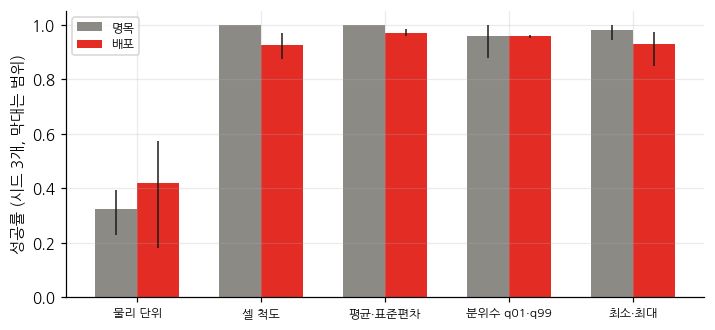

In [11]:
fig, ax = plt.subplots(figsize=(6.6, 3.1))
x = np.arange(len(HOW))
w = .34
for i, (c, col) in enumerate((("명목", GREY), ("배포", RED))):
    v = np.array([np.mean(SC[(h, c)]) for h in HOW])
    lo = v - np.array([min(SC[(h, c)]) for h in HOW])
    hi = np.array([max(SC[(h, c)]) for h in HOW]) - v
    ax.bar(x + (i - .5) * w, v, w, yerr=[lo, hi], color=col,
           label=c, error_kw=dict(lw=1, ecolor=INK))
ax.set_xticks(x)
ax.set_xticklabels(HOW, fontsize=8)
ax.set_ylabel("성공률 (시드 3개, 막대는 범위)")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

## 꼬리에 눌리는 몫

분위수 정규화는 q01 아래와 q99 위를 잘라 낸다. 차원이 여덟이면 한 차원이라도 잘리는 **행**의 비율은 1%보다 훨씬 커진다. 학습 데이터와, 전문가가 배포 조건에서 실제로 지나가는 상태(2장의 기준 상태) 양쪽에서 잰다.

최소·최대 정규화에는 반대 문제가 있다. 극단값 하나가 범위를 정하므로 **몸통이 좁은 구간에 눌린다.** 분위수 폭에 대한 최소·최대 폭의 비율로 잰다.

In [12]:
def ref_states(n=64, T=300, seed=77):
    env = Pert(n, seed, **COND["배포"])
    R = []
    for _ in range(T):
        R.append(env.obs())
        env.step(servo(env))
    return np.concatenate(R)


REF = ref_states()
REF_SI = REF.copy()
REF_SI[:, :8] /= 10.


def clipped(Z, lo, hi):
    out = (Z[:, :8] < lo) | (Z[:, :8] > hi)
    return out.any(1).mean(), out.mean()


LO = np.percentile(SI[:, :8], 1, 0)
HI = np.percentile(SI[:, :8], 99, 0)
r1, v1 = clipped(SI, LO, HI)
r2, v2 = clipped(REF_SI, LO, HI)
print("분위수 q01·q99 로 자를 때")
print("  (한 차원이라도 잘린 행 / 잘린 값)")
print(f"  학습 데이터    {r1:.1%} / {v1:.2%}")
print(f"  배포 기준 상태 {r2:.1%} / {v2:.2%}")
ratio = (SI[:, :8].max(0) - SI[:, :8].min(0)) / (HI - LO)
print("\n최소·최대 폭 / 분위수 폭 (차원별)")
print("  " + "  ".join(f"{r:.2f}" for r in ratio))
z8 = SI[:, :8]
zmax = np.abs((z8 - z8.mean(0)) / z8.std(0)).max(0)
print("\n평균·표준편차로 옮긴 뒤 |z| 의 최댓값 (차원별)")
print("  " + "  ".join(f"{z:.1f}" for z in zmax))

분위수 q01·q99 로 자를 때
  (한 차원이라도 잘린 행 / 잘린 값)
  학습 데이터    13.8% / 2.00%
  배포 기준 상태 12.5% / 1.89%

최소·최대 폭 / 분위수 폭 (차원별)
  1.09  1.20  1.28  1.56  1.32  1.39  1.35  1.37

평균·표준편차로 옮긴 뒤 |z| 의 최댓값 (차원별)
  2.1  2.7  2.8  3.6  4.3  2.8  3.6  3.2


## 통계를 어느 데이터에서 내는가

1부의 부 도입이 남긴 질문이다. 잡음 주입 데이터는 대본 전문가의 데이터보다 상태 분포가 넓다(2장, 점유 칸 187 → 498). 정규화 통계를 **좁은 쪽에서** 내고 넓은 쪽 데이터에 쓰면 얼마나 잘리고, 성적은 어떻게 되는가.

잡음 없는 전문가 궤적 4만 스텝을 모아 분위수 통계를 내고, 그 통계로 잡음 주입 데이터를 정규화해 학습한다.

In [13]:
XE, _ = dart(sig=0.)                     # 잡음 없는 대본 전문가
XE_SI = XE.copy()
XE_SI[:, :8] /= 10.
LOE = np.percentile(XE_SI[:, :8], 1, 0)
HIE = np.percentile(XE_SI[:, :8], 99, 0)
r3, v3 = clipped(SI, LOE, HIE)
r4, v4 = clipped(REF_SI, LOE, HIE)
print("전문가 데이터의 통계로 자를 때")
print(f"  학습 데이터   잘린 행 {r3:.1%}   잘린 값 {v3:.2%}")
print(f"  배포 기준 상태 잘린 행 {r4:.1%}   잘린 값 {v4:.2%}")


def q_from(lo, hi):
    def g(q):
        q = q.copy()
        u = 2 * (q[:, :8] - lo) / (hi - lo) - 1
        q[:, :8] = np.clip(u, -1, 1)
        return q.astype(np.float32)
    return g


fE = q_from(LOE, HIE)
k = "분위수 (전문가 통계)"
t0 = time.time()
for s in SEEDS:
    net = bc_any(fE(SI), Y, seed=s)
    for c in COND:
        rows = rollout(policy(net, fE), c, tag=s,
                       ver="norm-q-expert", **EV)
        LOG += rows
        SC.setdefault((k, c), []).append(rate(rows))
print(f"({time.time() - t0:.0f}s)\n")
show(["분위수 q01·q99", k], "통계의 출처", 20)

전문가 데이터의 통계로 자를 때
  학습 데이터   잘린 행 43.0%   잘린 값 7.79%
  배포 기준 상태 잘린 행 28.9%   잘린 값 4.38%


(44s)

통계의 출처             명목           범위    배포           범위
분위수 q01·q99         0.959   [0.88, 1.00]   0.958   [0.95, 0.96]
분위수 (전문가 통계)   0.948   [0.85, 1.00]   0.973   [0.95, 0.99]


## 좌표계 — 상대인가 절대인가

1장의 관측은 처음부터 **과제 기준 상대 좌표**였다 — 목표에서 부품까지, 부품에서 밀대까지. 작업대 기준 절대 좌표로 같은 정보를 주면 어떻게 되는가.

절대 좌표 관측은 부품 위치, 밀대 위치, 목표 위치(각 2차원), 두 속도, 종류 표시로 12차원이다. 담긴 정보는 같다 — 상대 좌표는 절대 좌표의 뺄셈으로 만들 수 있다. 배포 조건의 관측 편향은 두 좌표계 모두에서 **부품 위치**에 붙는다. 두 좌표계 모두 평균·표준편차로 정규화한다.

In [14]:
def world(env):
    """작업대 기준 절대 좌표 (셀 척도)"""
    o = env.obs()
    w = np.zeros((env.n, 12), np.float32)
    for i, d in enumerate(env.d):
        w[i, 0:2] = d.qpos[0:2] * 10.
        w[i, 2:4] = d.qpos[7:9] * 10.
        w[i, 4:6] = env.g[i] * 10.
    w[:, 6:10] = o[:, [2, 3, 6, 7]]
    w[:, 10:12] = o[:, 8:10]
    if hasattr(env, "bias"):        # 관측 편향은 부품 위치에 붙는다
        w[:, 0:2] += np.float32(env.bias * 10.)
    return w


def dart_both(steps=40_000, n=64, seed=5):
    rng = np.random.default_rng(seed)
    env = Cell(n, seed)
    R, W, L = [], [], []
    while len(R) * n < steps:
        R.append(env.obs())
        W.append(world(env))
        ex = servo(env)
        L.append(ex)
        act = np.clip(ex + rng.normal(0, SIG, ex.shape), -1, 1)
        env.step(act.astype(np.float32))
    cut = lambda z: np.concatenate(z)[:steps].astype(np.float32)
    return cut(R), cut(W), cut(L)


def zfit(Z):
    mu, sd = Z.mean(0), Z.std(0) + 1e-6
    sd[-2:], mu[-2:] = 1., 0.             # 종류 표시는 그대로
    return lambda q: ((q - mu) / sd).astype(np.float32)


XR, XW, YF = dart_both()
t0 = time.time()
for nm, Xs, view in (("상대 좌표", XR, lambda e: e.obs()),
                     ("절대 좌표", XW, world)):
    f = zfit(Xs)
    for s in SEEDS:
        net = bc_any(f(Xs), YF, seed=s)
        for c in COND:
            rows = rollout(policy(net, f, view), c, tag=s,
                           ver=f"frame-{nm}", **EV)
            LOG += rows
            SC.setdefault((nm, c), []).append(rate(rows))
    print(f"  {nm} 끝  ({time.time() - t0:.0f}s)", flush=True)
print()
show(["상대 좌표", "절대 좌표"], "좌표계")

  상대 좌표 끝  (41s)


  절대 좌표 끝  (83s)



좌표계              명목           범위    배포           범위
상대 좌표          1.000   [1.00, 1.00]   0.969   [0.97, 0.98]
절대 좌표          0.967   [0.92, 1.00]   0.824   [0.73, 0.91]


## 정규화 통계를 고정한다

고르는 규칙을 코드로 적는다. **명목 평균이 0.99 이상인 방식 가운데 배포 평균이 가장 높은 것.** 통계는 잡음 주입 데이터 전체에서 내고, 좌표계는 상대 좌표를 유지한다. 행동은 이미 [−1, 1] 안에 있으므로 정규화하지 않는다.

In [15]:
cand = [h for h in HOW if np.mean(SC[(h, "명목")]) >= .99] or HOW
pick = max(cand, key=lambda h: np.mean(SC[(h, "배포")]))
z = SI[:, :8]
STATS = {"method": pick, "frame": "relative", "units": "SI",
         "dims": NAMES[:8], "passthrough": NAMES[8:],
         "mean": z.mean(0).round(6).tolist(),
         "std": (z.std(0) + 1e-8).round(6).tolist(),
         "q01": np.percentile(z, 1, 0).round(6).tolist(),
         "q99": np.percentile(z, 99, 0).round(6).tolist(),
         "min": z.min(0).round(6).tolist(),
         "max": z.max(0).round(6).tolist(),
         "source": "data/demos_v1.npz", "rows": int(len(z))}
os.makedirs("data", exist_ok=True)
with open("data/norm_stats.json", "w") as f:
    json.dump(STATS, f, ensure_ascii=False, indent=1)
save_log("report/ch04_log.csv", LOG)
print(f"명목 0.99 이상: {', '.join(cand)}")
dep = np.mean(SC[(pick, "배포")])
print(f"고른 방식      : {pick}  (배포 {dep:.3f})")
print()
print("남긴 산출물")
print(f"  data/norm_stats.json  방식·좌표계·통계 ({len(z):,}행)")
print(f"  report/ch04_log.csv   판별 로그 {len(LOG):,}줄")

명목 0.99 이상: 셀 척도, 평균·표준편차
고른 방식      : 평균·표준편차  (배포 0.971)

남긴 산출물
  data/norm_stats.json  방식·좌표계·통계 (40,000행)
  report/ch04_log.csv   판별 로그 17,012줄


## 정리

**정규화를 하느냐가 방식보다 크다.** 물리 단위 그대로는 명목 0.324, 정규화한 네 방식은 배포 0.92~0.97이다. 방식 사이의 차이는 대부분 시드 범위 안이다.

**분위수로 자르면 행의 13.8%가 잘린다.** 차원마다 1%씩이어도 여덟 차원이면 그렇다. 좁은 데이터에서 낸 통계로 자르면 43.0%까지 오르는데, 이 과제에서는 성적이 떨어지지 않았다.

**좌표계가 정규화보다 크다.** 같은 정보를 상대 좌표로 주면 배포 0.969, 절대 좌표로 주면 0.824다.

**고른 것은 평균·표준편차, 상대 좌표, 잡음 주입 데이터 전체의 통계다.** `data/norm_stats.json` 에 방식과 함께 다섯 가지 통계를 모두 적었다. 3부가 방식을 바꾸고 싶으면 다시 모을 필요 없이 이 파일에서 고르면 된다.